In [1]:
import matplotlib.pyplot as plt
import numpy as np
from tapas_gmm_modified.policy.models.tpgmm import (
    ReconstructionStrategy, 
    FittingStage,
    InitStrategy,

)
from tapas_gmm_modified.dataset.demos import Demos
from tapas_gmm_modified.viz.gmm import plot_hmm_transition_matrix

np.set_printoptions(precision=2)

plt.style.use('default')

from matplotlib import rc
rc('animation', html='jshtml')

2026-07-07 02:37:13.419 | INFO     |  Running on cpu


/home/jangruhnert/miniconda3/envs/hecarim/lib/python3.10/site-packages/riepybdlib/data.py:34: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_listdir


In [2]:
from heca.agents.experts.tapas import TapasAgent
from conf.agents.experts.tapas import unlock_right as agent_cfg
agent = TapasAgent.get(agent_cfg, auto_load=True)
print(agent_cfg.policy.model.frame_selection.gt_frames)
selections = [0, 1, 3, 4, 5]

2026-07-07 02:37:15.338 | INFO     | heca.misc.logger:info:30 - Running on cpu


/home/jangruhnert/miniconda3/envs/hecarim/lib/python3.10/site-packages/gymnasium/spaces/box.py:231: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/jangruhnert/miniconda3/envs/hecarim/lib/python3.10/site-packages/gymnasium/spaces/box.py:297: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


2026-07-07 02:37:17.320 | INFO     | heca.misc.logger:info:30 - Loading <class 'heca.agents.experts.tapas.TapasAgent'> from /home/jangruhnert/Documents/GitHub/master-project/data/agents/tapas/unlock_right_button
2026-07-07 02:37:17.320 | INFO     | tapas_gmm_modified.utils.logging:wrapper:67 - Initializing Policy:
2026-07-07 02:37:17.320 | INFO     | tapas_gmm_modified.encoder:get_image_encoder_class:62 - No encoder config provided. Using None.
2026-07-07 02:37:17.321 | WARNING  | heca.misc.logger:warning:26 - No tapas policy found at given path: /home/jangruhnert/Documents/GitHub/master-project/data/agents/tapas/unlock_right_button/policy_gt.pt
GMMPolicy(
  (obs_encoder): ObservationEncoder()
)
[[0, 3], [3, 7]]


In [3]:
observations = agent.load_demos(selections)

demos = Demos(
    observations,
    add_init_ee_pose_as_frame=True,
    add_world_frame=False,
    frames_from_keypoints=False,
    kp_indeces=None,
    enforce_z_up=False,
    modulo_object_z_rotation=False,
    make_quats_continuous=True,
)  # type: ignore
print("n_trajs", demos.n_trajs)
print("n_frames", demos.n_frames)
demos.frame_names


2026-07-07 02:37:29.105 | INFO     | tapas_gmm_modified.dataset.demos:subsample_to_common_length:609 - Subsampling to length 38 using strategy mean-length.
n_trajs 5
n_frames 8


('ee_init',
 'block_0',
 'button_0',
 'button_1',
 'drawer_handle',
 'window_handle',
 'block_0_target',
 'ee_target')

2026-07-07 02:37:29.112 | INFO     | tapas_gmm_modified.policy.models.tpgmm:fit_trajectories:2740 - Fitting AutoTPGMM
2026-07-07 02:37:29.113 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_select_fitting_actions:1088 - Performing fitting actions: [INIT]
2026-07-07 02:37:29.113 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_segment_and_frame_select:2860 - Segmenting trajectories


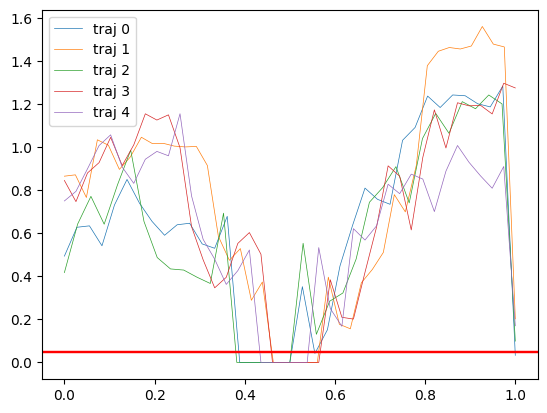

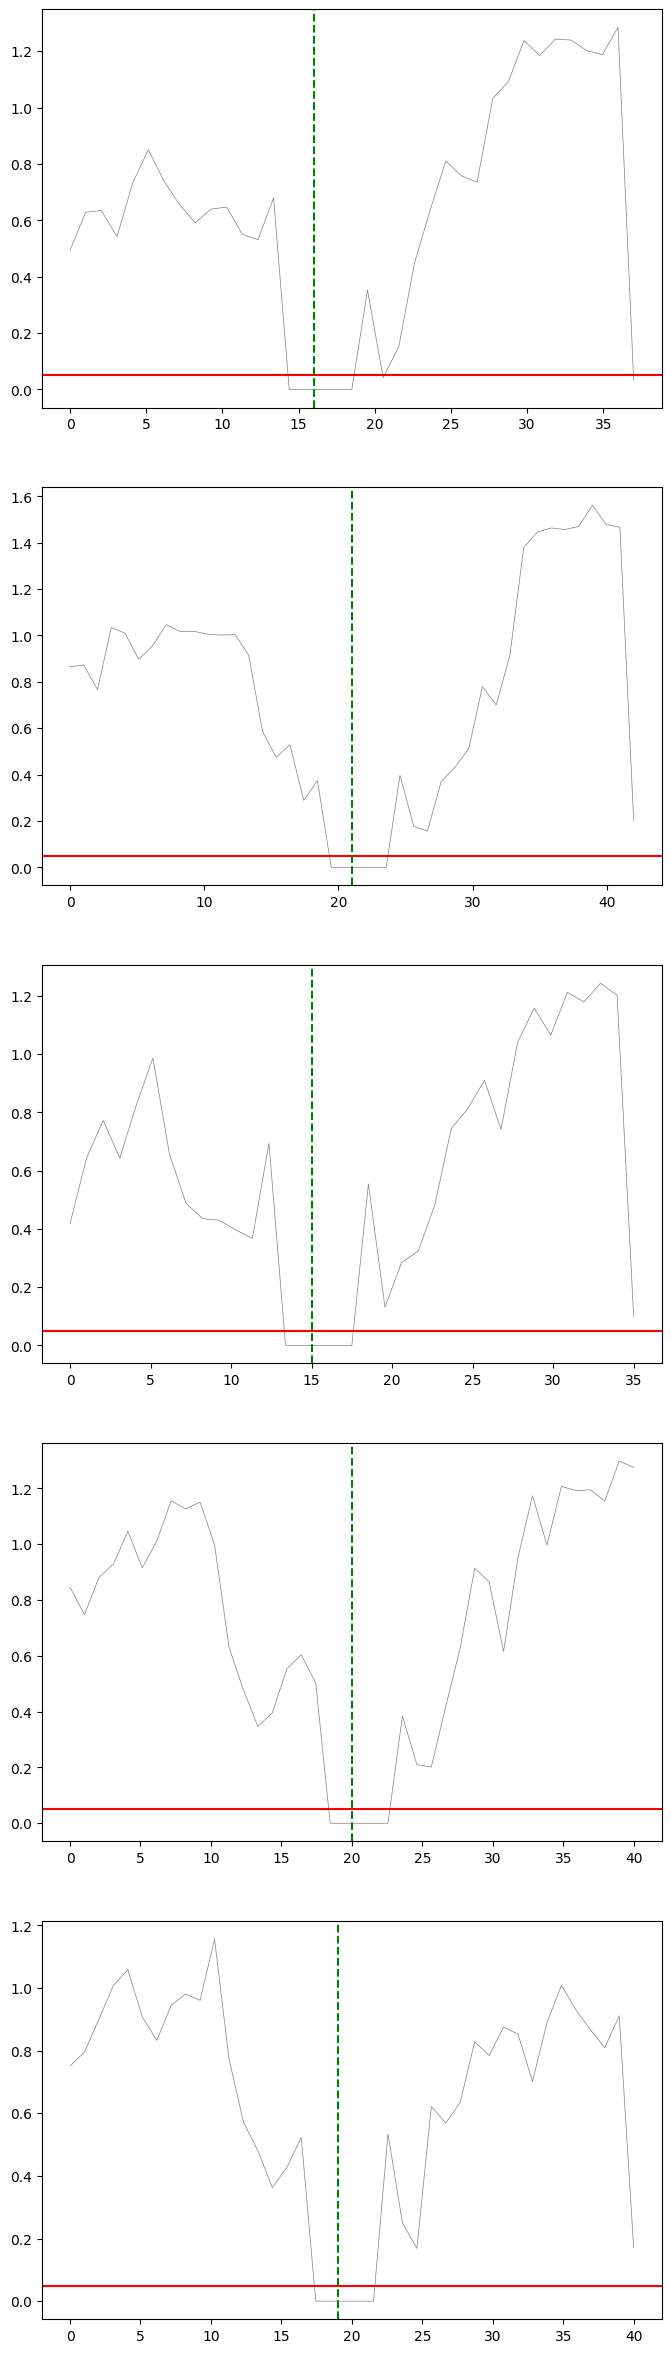

2026-07-07 02:37:29.405 | INFO     | tapas_gmm_modified.dataset.demos:__init__:2697 - Creating segement of demos.
2026-07-07 02:37:29.406 | INFO     | tapas_gmm_modified.dataset.demos:subsample_to_common_length:609 - Subsampling to length 18 using strategy mean-length.
2026-07-07 02:37:29.406 | INFO     | tapas_gmm_modified.dataset.demos:__init__:2697 - Creating segement of demos.
2026-07-07 02:37:29.407 | INFO     | tapas_gmm_modified.dataset.demos:subsample_to_common_length:609 - Subsampling to length 20 using strategy mean-length.
2026-07-07 02:37:29.407 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_segment_and_frame_select:2865 - ... created 2 segments
2026-07-07 02:37:29.407 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_fit_frames:3043 - Fitting candidate frame 1/8
2026-07-07 02:37:29.407 | INFO     | tapas_gmm_modified.dataset.demos:__init__:2470 - Creating partial frame view of demos.
2026-07-07 02:37:29.407 | INFO     | tapas_gmm_modified.dataset.demos:subsample_t

Time-based init:   0%|          | 0/9 [00:00<?, ?it/s]

2026-07-07 02:37:29.474 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_fit_frames:3043 - Fitting candidate frame 2/8
2026-07-07 02:37:29.474 | INFO     | tapas_gmm_modified.dataset.demos:__init__:2470 - Creating partial frame view of demos.
2026-07-07 02:37:29.474 | INFO     | tapas_gmm_modified.dataset.demos:subsample_to_common_length:609 - Subsampling to length 18 using strategy mean-length.
2026-07-07 02:37:29.477 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_setup_manifold:735 - Manifold: TIME x R3 x QUAT x R1
2026-07-07 02:37:29.477 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 9
2026-07-07 02:37:29.477 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_select_fitting_actions:1088 - Performing fitting actions: [INIT]
2026-07-07 02:37:29.477 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_fit_rbd_init:1195 - Model init ...


Time-based init:   0%|          | 0/9 [00:00<?, ?it/s]

2026-07-07 02:37:29.529 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_fit_frames:3043 - Fitting candidate frame 3/8
2026-07-07 02:37:29.529 | INFO     | tapas_gmm_modified.dataset.demos:__init__:2470 - Creating partial frame view of demos.
2026-07-07 02:37:29.529 | INFO     | tapas_gmm_modified.dataset.demos:subsample_to_common_length:609 - Subsampling to length 18 using strategy mean-length.
2026-07-07 02:37:29.532 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_setup_manifold:735 - Manifold: TIME x R3 x QUAT x R1
2026-07-07 02:37:29.532 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 9
2026-07-07 02:37:29.532 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_select_fitting_actions:1088 - Performing fitting actions: [INIT]
2026-07-07 02:37:29.532 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_fit_rbd_init:1195 - Model init ...


...

2026-07-07 02:37:30.613 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_setup_manifold:735 - Manifold: TIME x R3 x QUAT x R3 x QUAT x R1
2026-07-07 02:37:30.613 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 9
2026-07-07 02:37:30.613 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_select_fitting_actions:1088 - Performing fitting actions: [INIT]
2026-07-07 02:37:30.614 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_fit_rbd_init:1195 - Model init ...


Time-based init:   0%|          | 0/9 [00:00<?, ?it/s]

2026-07-07 02:37:30.730 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_setup_manifold:735 - Manifold: TIME x R3 x QUAT x R3 x QUAT x R1
2026-07-07 02:37:30.731 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 10
2026-07-07 02:37:30.731 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_select_fitting_actions:1088 - Performing fitting actions: [INIT]
2026-07-07 02:37:30.731 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_fit_rbd_init:1195 - Model init ...


Time-based init:   0%|          | 0/10 [00:00<?, ?it/s]

((array([[9.39e+012, 1.02e+013, 3.15e+010, 1.66e+005, 3.57e-002, 5.35e-003,
          3.10e-010, 3.69e-025, 1.09e-047, 1.68e-058, 5.88e-072, 7.42e-082,
          3.78e-090, 2.09e-093, 3.02e-105, 2.19e-114, 4.81e-121, 2.36e-126,
          1.34e+013, 1.81e+013, 9.99e+011, 1.86e+009, 1.45e+003, 1.35e-009,
          9.86e-020, 1.02e-027, 9.33e-045, 3.81e-082, 1.42e-097, 6.18e-102,
          1.55e-108, 2.97e-119, 5.45e-127, 3.31e-134, 1.20e-139, 1.32e-144,
          1.85e+013, 1.70e+013, 8.76e+010, 2.86e+010, 4.56e+003, 2.63e-006,
          7.19e-022, 1.40e-041, 4.09e-060, 3.13e-061, 5.92e-066, 5.19e-080,
          9.52e-088, 1.23e-096, 2.89e-105, 3.86e-109, 4.85e-117, 5.16e-122,
          2.30e+013, 3.00e+013, 3.45e+012, 1.77e+010, 9.94e+005, 4.92e-012,
          8.18e-020, 2.41e-032, 1.95e-051, 3.24e-068, 4.03e-087, 4.19e-098,
          2.65e-108, 1.13e-118, 2.06e-122, 6.54e-131, 4.46e-134, 8.94e-139,
          2.89e+013, 2.78e+013, 2.49e+012, 1.15e+011, 1.27e+006, 4.63e-003,
          5.

In [4]:
agent.model.fit_trajectories(demos, fix_frames=True,
                       init_strategy=InitStrategy.TIME_BASED,
                       fitting_actions=(FittingStage.INIT,))


2026-07-07 02:37:30.875 | INFO     | tapas_gmm_modified.policy.models.tpgmm:plot_model:3856 - Did not specify time_based, deciding automatically.
2026-07-07 02:37:30.931 | WARNING  | tapas_gmm_modified.viz.gmm:plot_gmm_time_based:538 - Skippig NaN Gaussians.
2026-07-07 02:37:30.931 | WARNING  | tapas_gmm_modified.viz.gmm:plot_gmm_time_based:538 - Skippig NaN Gaussians.
2026-07-07 02:37:30.931 | WARNING  | tapas_gmm_modified.viz.gmm:plot_gmm_time_based:538 - Skippig NaN Gaussians.
2026-07-07 02:37:30.931 | WARNING  | tapas_gmm_modified.viz.gmm:plot_gmm_time_based:538 - Skippig NaN Gaussians.
2026-07-07 02:37:30.931 | WARNING  | tapas_gmm_modified.viz.gmm:plot_gmm_time_based:538 - Skippig NaN Gaussians.
2026-07-07 02:37:30.931 | WARNING  | tapas_gmm_modified.viz.gmm:plot_gmm_time_based:538 - Skippig NaN Gaussians.
2026-07-07 02:37:30.931 | WARNING  | tapas_gmm_modified.viz.gmm:plot_gmm_time_based:538 - Skippig NaN Gaussians.
2026-07-07 02:37:30.931 | WARNING  | tapas_gmm_modified.viz.gmm

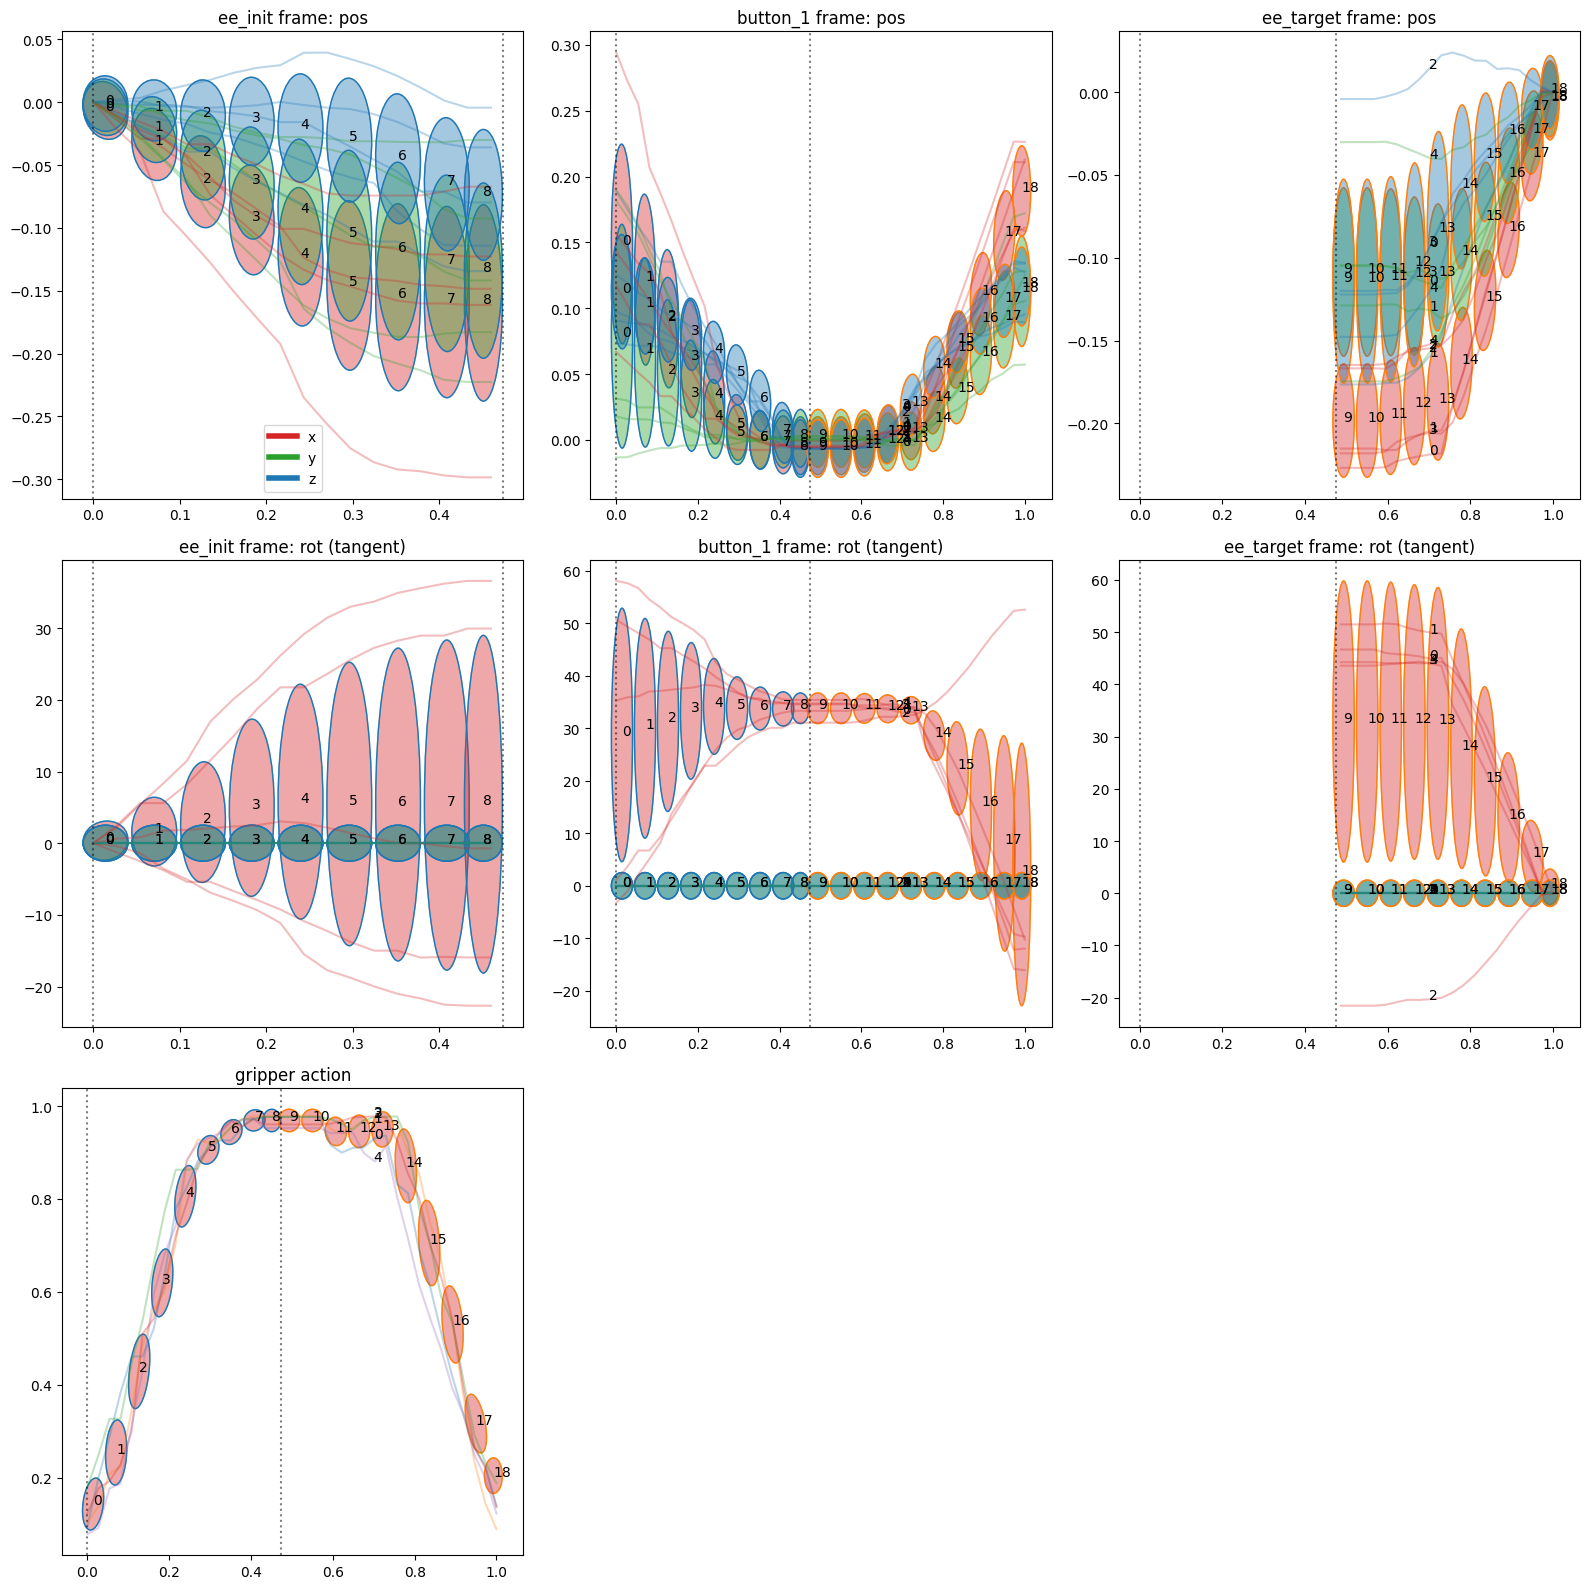

In [5]:
agent.model.plot_model(scatter=True, annotate_gaussians=True, annotate_trajs=True, mean_as_base=False)


In [6]:
agent.model.fit_trajectories(demos, fix_frames=True, fitting_actions=(FittingStage.EM_HMM, ))


2026-07-07 02:37:32.534 | INFO     | tapas_gmm_modified.policy.models.tpgmm:fit_trajectories:2740 - Fitting AutoTPGMM
2026-07-07 02:37:32.534 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_select_fitting_actions:1088 - Performing fitting actions: [EM_HMM]


Fitting segments:   0%|          | 0/2 [00:00<?, ?it/s]

2026-07-07 02:37:32.537 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_select_fitting_actions:1088 - Performing fitting actions: [EM_HMM]
2026-07-07 02:37:32.537 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_fit_rbd_hmm:1296 - HMM EM ...
2026-07-07 02:37:32.541 | INFO     | riepybdlib.statistics:trans:1710 - HMM transition matrix not defined, initializing to uniform


HMM EM:   0%|          | 0/50 [00:00<?, ?it/s]

2026-07-07 02:37:32.559 | INFO     | riepybdlib.statistics:init_priors:1698 - HMM init priors not defined, initializing to uniform
2026-07-07 02:37:35.797 | INFO     | riepybdlib.statistics:em:2249 - HMM EM converged
2026-07-07 02:37:35.828 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_select_fitting_actions:1088 - Performing fitting actions: [EM_HMM]
2026-07-07 02:37:35.828 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_fit_rbd_hmm:1296 - HMM EM ...
2026-07-07 02:37:35.831 | INFO     | riepybdlib.statistics:trans:1710 - HMM transition matrix not defined, initializing to uniform


HMM EM:   0%|          | 0/50 [00:00<?, ?it/s]

2026-07-07 02:37:35.854 | INFO     | riepybdlib.statistics:init_priors:1698 - HMM init priors not defined, initializing to uniform
2026-07-07 02:37:39.363 | INFO     | riepybdlib.statistics:em:2249 - HMM EM converged


((array([[1.00e+000, 9.74e-001, 4.38e-002, 1.04e-007, 2.47e-018, 1.15e-038,
          3.17e-073, 6.85e-124, 6.69e-191, 3.51e-275, 0.00e+000, 0.00e+000,
          0.00e+000, 0.00e+000, 0.00e+000, 0.00e+000, 0.00e+000, 0.00e+000,
          1.00e+000, 1.00e+000, 1.00e+000, 1.92e-005, 1.46e-018, 7.82e-049,
          4.80e-100, 1.74e-173, 1.59e-270, 0.00e+000, 0.00e+000, 0.00e+000,
          0.00e+000, 0.00e+000, 0.00e+000, 0.00e+000, 0.00e+000, 0.00e+000,
          1.00e+000, 6.64e-001, 1.10e-003, 2.98e-008, 1.27e-020, 1.50e-046,
          1.79e-085, 1.60e-140, 2.41e-211, 3.09e-297, 0.00e+000, 0.00e+000,
          0.00e+000, 0.00e+000, 0.00e+000, 0.00e+000, 0.00e+000, 0.00e+000,
          1.00e+000, 9.85e-001, 1.04e-002, 3.42e-010, 9.10e-033, 9.08e-075,
          1.01e-137, 7.20e-224, 0.00e+000, 0.00e+000, 0.00e+000, 0.00e+000,
          0.00e+000, 0.00e+000, 0.00e+000, 0.00e+000, 0.00e+000, 0.00e+000,
          1.00e+000, 9.14e-001, 6.39e-002, 2.27e-006, 1.00e-016, 7.59e-039,
          1.

2026-07-07 02:37:39.455 | WARNING  | tapas_gmm_modified.viz.gmm:plot_gmm_time_based:538 - Skippig NaN Gaussians.
2026-07-07 02:37:39.455 | WARNING  | tapas_gmm_modified.viz.gmm:plot_gmm_time_based:538 - Skippig NaN Gaussians.
2026-07-07 02:37:39.455 | WARNING  | tapas_gmm_modified.viz.gmm:plot_gmm_time_based:538 - Skippig NaN Gaussians.
2026-07-07 02:37:39.455 | WARNING  | tapas_gmm_modified.viz.gmm:plot_gmm_time_based:538 - Skippig NaN Gaussians.
2026-07-07 02:37:39.455 | WARNING  | tapas_gmm_modified.viz.gmm:plot_gmm_time_based:538 - Skippig NaN Gaussians.
2026-07-07 02:37:39.455 | WARNING  | tapas_gmm_modified.viz.gmm:plot_gmm_time_based:538 - Skippig NaN Gaussians.
2026-07-07 02:37:39.455 | WARNING  | tapas_gmm_modified.viz.gmm:plot_gmm_time_based:538 - Skippig NaN Gaussians.
2026-07-07 02:37:39.455 | WARNING  | tapas_gmm_modified.viz.gmm:plot_gmm_time_based:538 - Skippig NaN Gaussians.
2026-07-07 02:37:39.455 | WARNING  | tapas_gmm_modified.viz.gmm:plot_gmm_time_based:538 - Skippi

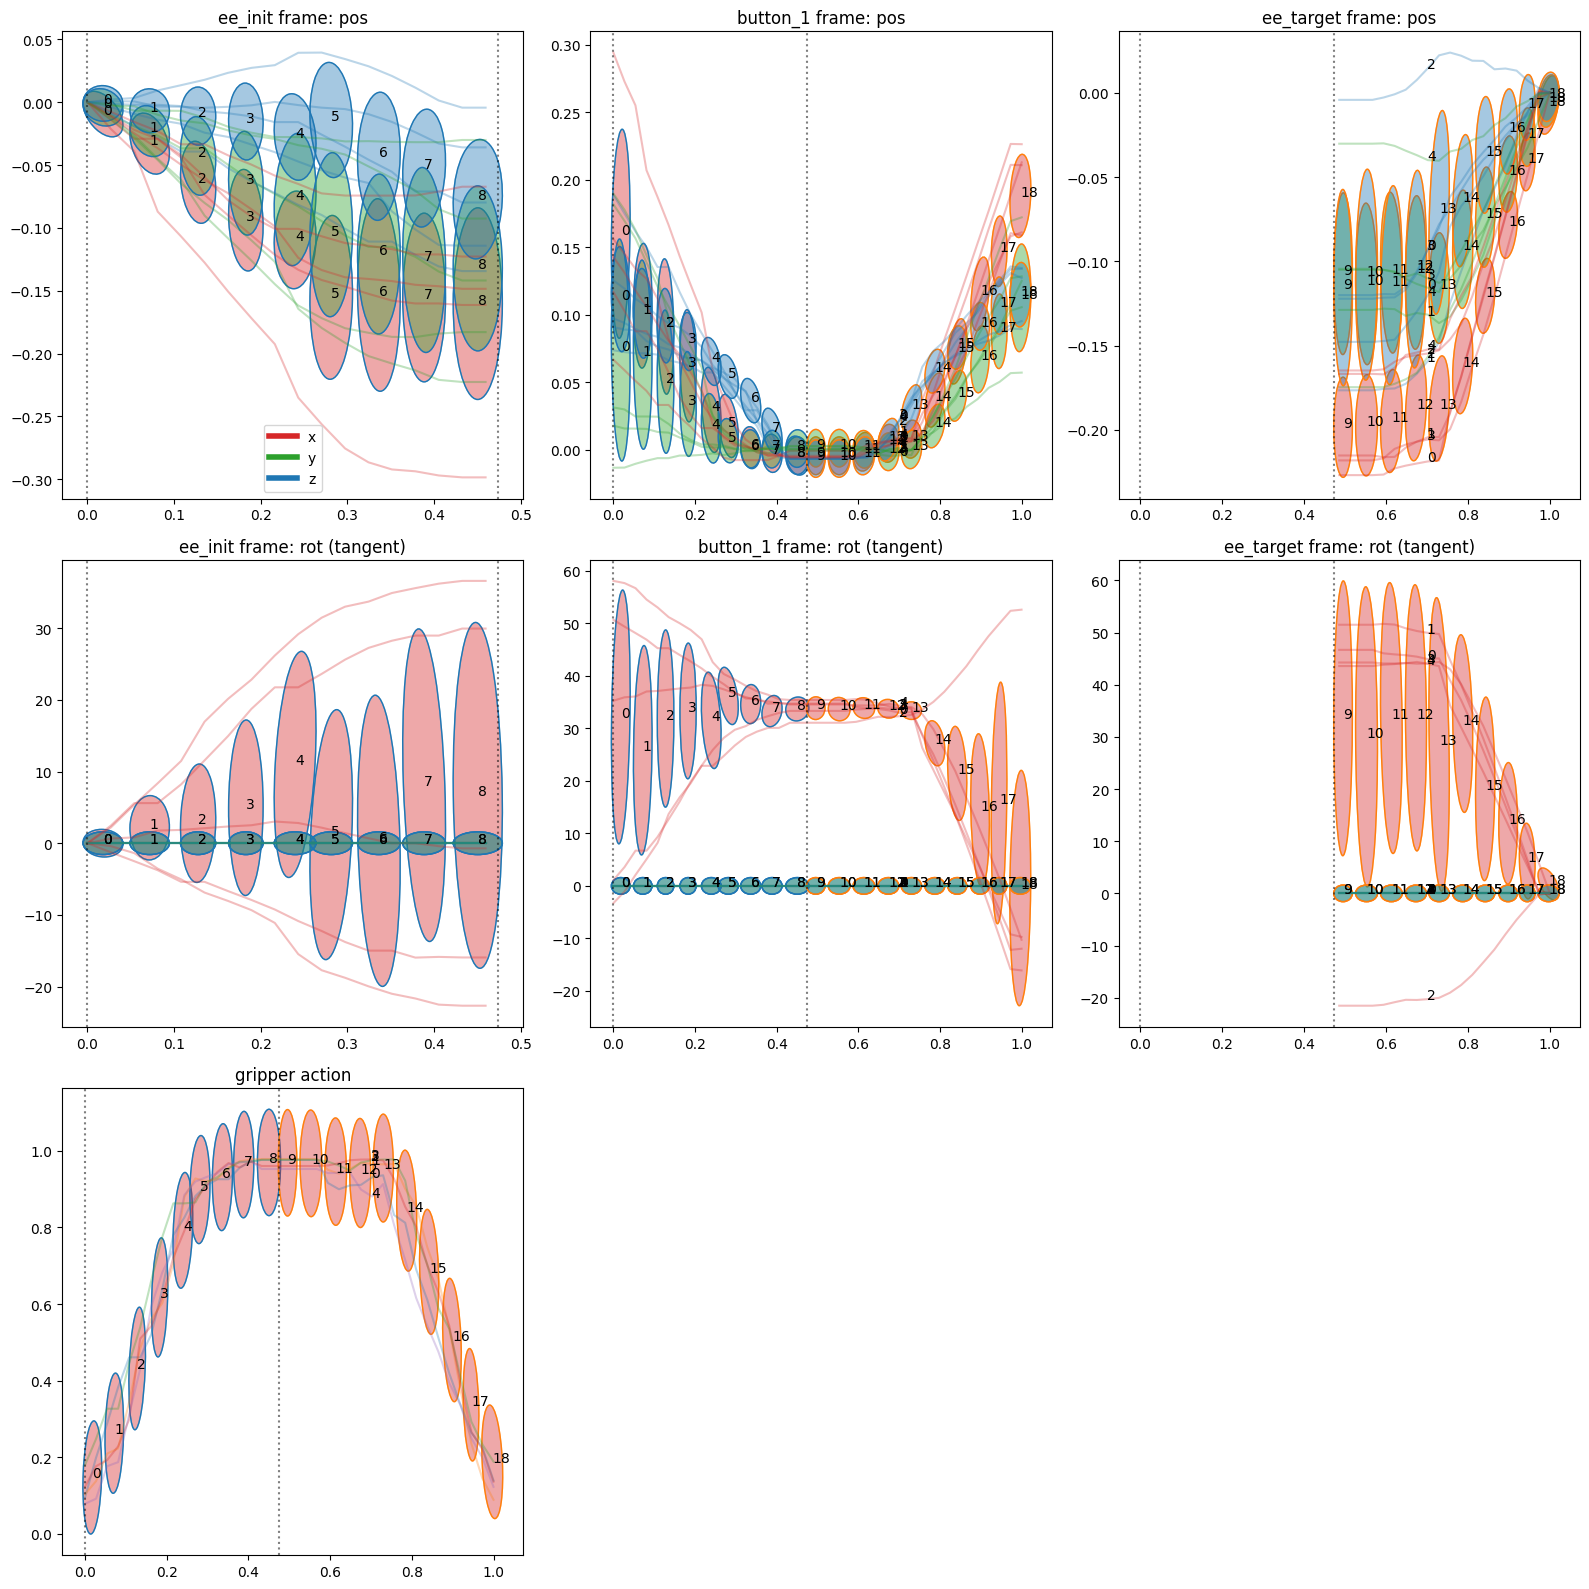

In [7]:
agent.model.plot_model(
    scatter=True, annotate_gaussians=True, annotate_trajs=True, mean_as_base=False, time_based=True,
)

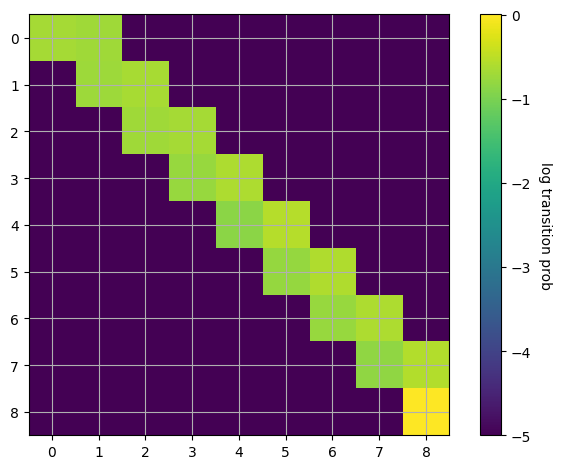

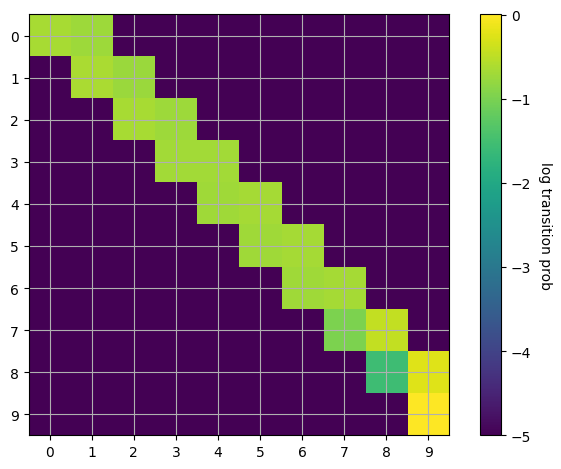

In [8]:
agent.model.plot_hmm_transition_matrix()

In [9]:
agent.save()

2026-07-07 02:37:41.028 | INFO     | heca.misc.logger:info:30 - Saving <class 'heca.agents.experts.tapas.TapasAgent'> to /home/jangruhnert/Documents/GitHub/master-project/data/agents/tapas/unlock_right_button
2026-07-07 02:37:41.028 | INFO     | heca.misc.logger:info:30 - Saving tapas policy to: /home/jangruhnert/Documents/GitHub/master-project/data/agents/tapas/unlock_right_button/policy_gt.pt
2026-07-07 02:37:41.028 | INFO     | tapas_gmm_modified.policy.models.tpgmm:to_disk:2617 - Saving model:


In [10]:
seg_local_marginals, seg_trans_marginals, seg_trans_marg_container, seg_joint_models, cascaded_hmms, (reconstructions, original_trajectories, extras) = agent.model.reconstruct(
    strategy=ReconstructionStrategy.GMR,
    use_ss=False)


2026-07-07 02:37:41.062 | INFO     | tapas_gmm_modified.policy.models.tpgmm:reconstruct:3239 - Time-based reconstruction not specified. Auto selected True.
2026-07-07 02:37:46.395 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_cascade_segment_hmms:3343 - Caculated segment transition probabilities: (array([[0.14]]),)
2026-07-07 02:37:46.395 | INFO     | tapas_gmm_modified.dataset.demos:__init__:2470 - Creating partial frame view of demos.
2026-07-07 02:37:46.395 | INFO     | tapas_gmm_modified.dataset.demos:subsample_to_common_length:609 - Subsampling to length 38 using strategy mean-length.
2026-07-07 02:37:46.396 | INFO     | tapas_gmm_modified.dataset.demos:_frame_quats2world_velocities:807 - Assuming zero frame velocity. Should be fixed.
2026-07-07 02:37:46.397 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 9
2026-07-07 02:37:46.397 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 9


Transforming marginals:   0%|          | 0/5 [00:00<?, ?it/s]

2026-07-07 02:37:46.402 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 9
2026-07-07 02:37:46.407 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 9
2026-07-07 02:37:46.410 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 9
2026-07-07 02:37:46.413 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 9
2026-07-07 02:37:46.416 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 9
2026-07-07 02:37:46.419 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 9
2026-07-07 02:37:46.421 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 9
2026-07-07 02:37:46.424 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 9
2026-07-07 02:37:46.427 | INFO     | riepybdlib.statistics:set_n

Joining marginals:   0%|          | 0/5 [00:00<?, ?it/s]

2026-07-07 02:37:46.437 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 9
2026-07-07 02:37:46.447 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 9
2026-07-07 02:37:46.457 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 9
2026-07-07 02:37:46.466 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 9
2026-07-07 02:37:46.474 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 9
2026-07-07 02:37:46.480 | INFO     | tapas_gmm_modified.dataset.demos:__init__:2470 - Creating partial frame view of demos.
2026-07-07 02:37:46.480 | INFO     | tapas_gmm_modified.dataset.demos:subsample_to_common_length:609 - Subsampling to length 38 using strategy mean-length.
2026-07-07 02:37:46.481 | INFO     | tapas_gmm_modified.dataset.demos:_frame_quats2world_velocities:807 - Assuming zero frame velocity.

...

2026-07-07 02:37:46.485 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 10
2026-07-07 02:37:46.489 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 10
2026-07-07 02:37:46.492 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 10
2026-07-07 02:37:46.495 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 10
2026-07-07 02:37:46.498 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 10
2026-07-07 02:37:46.501 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 10
2026-07-07 02:37:46.505 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 10
2026-07-07 02:37:46.508 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 10
2026-07-07 02:37:46.511 | INFO     | riepybdlib.statisti

Joining marginals:   0%|          | 0/5 [00:00<?, ?it/s]

2026-07-07 02:37:46.521 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 10
2026-07-07 02:37:46.532 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 10
2026-07-07 02:37:46.542 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 10
2026-07-07 02:37:46.553 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 10
2026-07-07 02:37:46.563 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 10
2026-07-07 02:37:46.574 | WARNING  | riepybdlib.statistics:__init__:2454 - Setting init priors of later segments to zero.
2026-07-07 02:37:46.575 | WARNING  | riepybdlib.statistics:__init__:2454 - Setting init priors of later segments to zero.
2026-07-07 02:37:46.575 | WARNING  | riepybdlib.statistics:__init__:2454 - Setting init priors of later segments to zero.
2026-07-07 02:37:46.575 | WARNING  | riepybd

GMR:   0%|          | 0/5 [00:00<?, ?it/s]

2026-07-07 02:37:46.580 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 9
2026-07-07 02:37:46.580 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 10
2026-07-07 02:37:46.775 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 9
2026-07-07 02:37:46.775 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 10
2026-07-07 02:37:46.987 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 9
2026-07-07 02:37:46.988 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 10
2026-07-07 02:37:47.141 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 9
2026-07-07 02:37:47.141 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 10
2026-07-07 02:37:47.319 | INFO     | riepybdlib.statistics:s

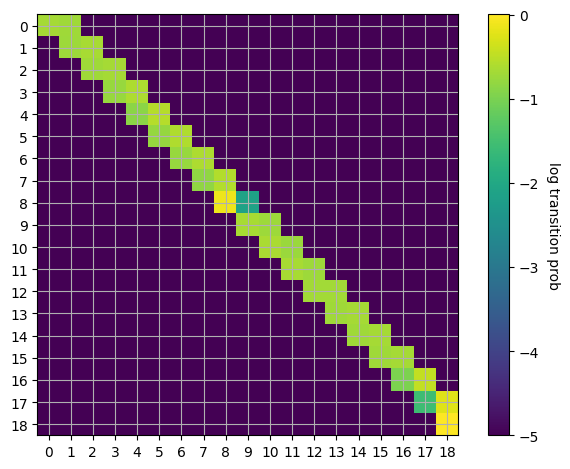

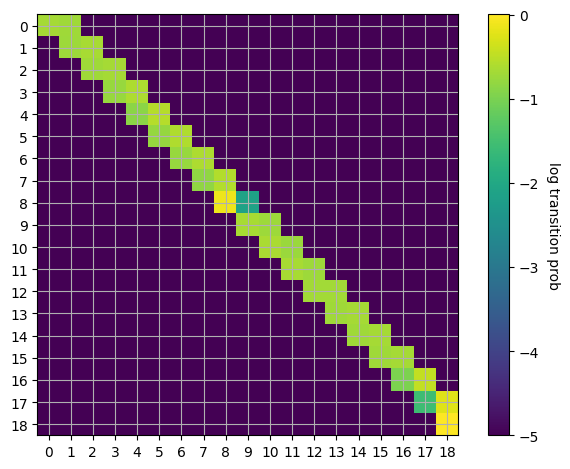

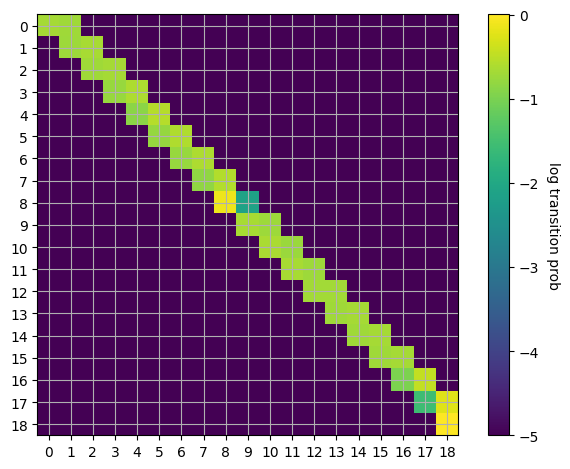

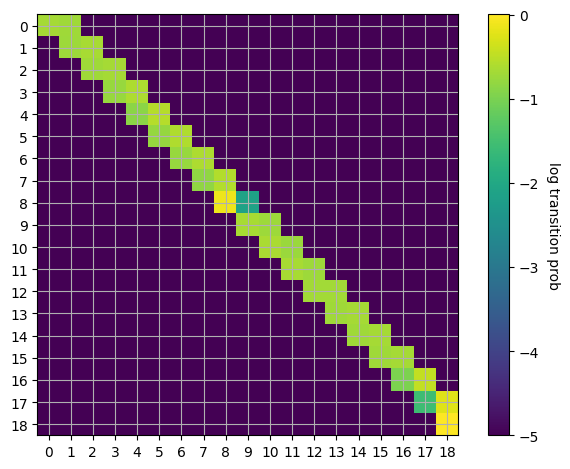

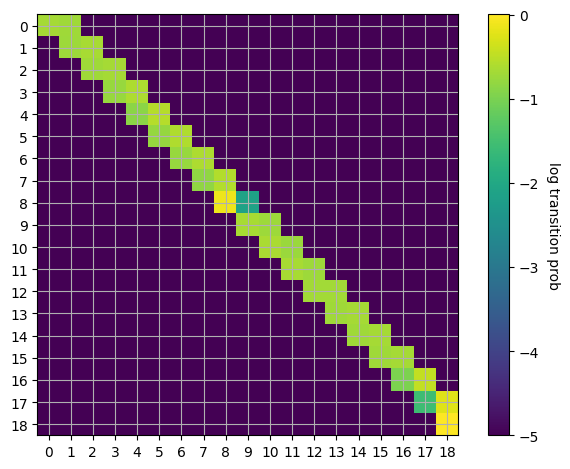

In [11]:
for cascaded_hmm in cascaded_hmms:
    plot_hmm_transition_matrix(cascaded_hmm)

2026-07-07 02:37:48.044 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_plot_reconstructions_jointly:4105 - Taking frame origins from demos.


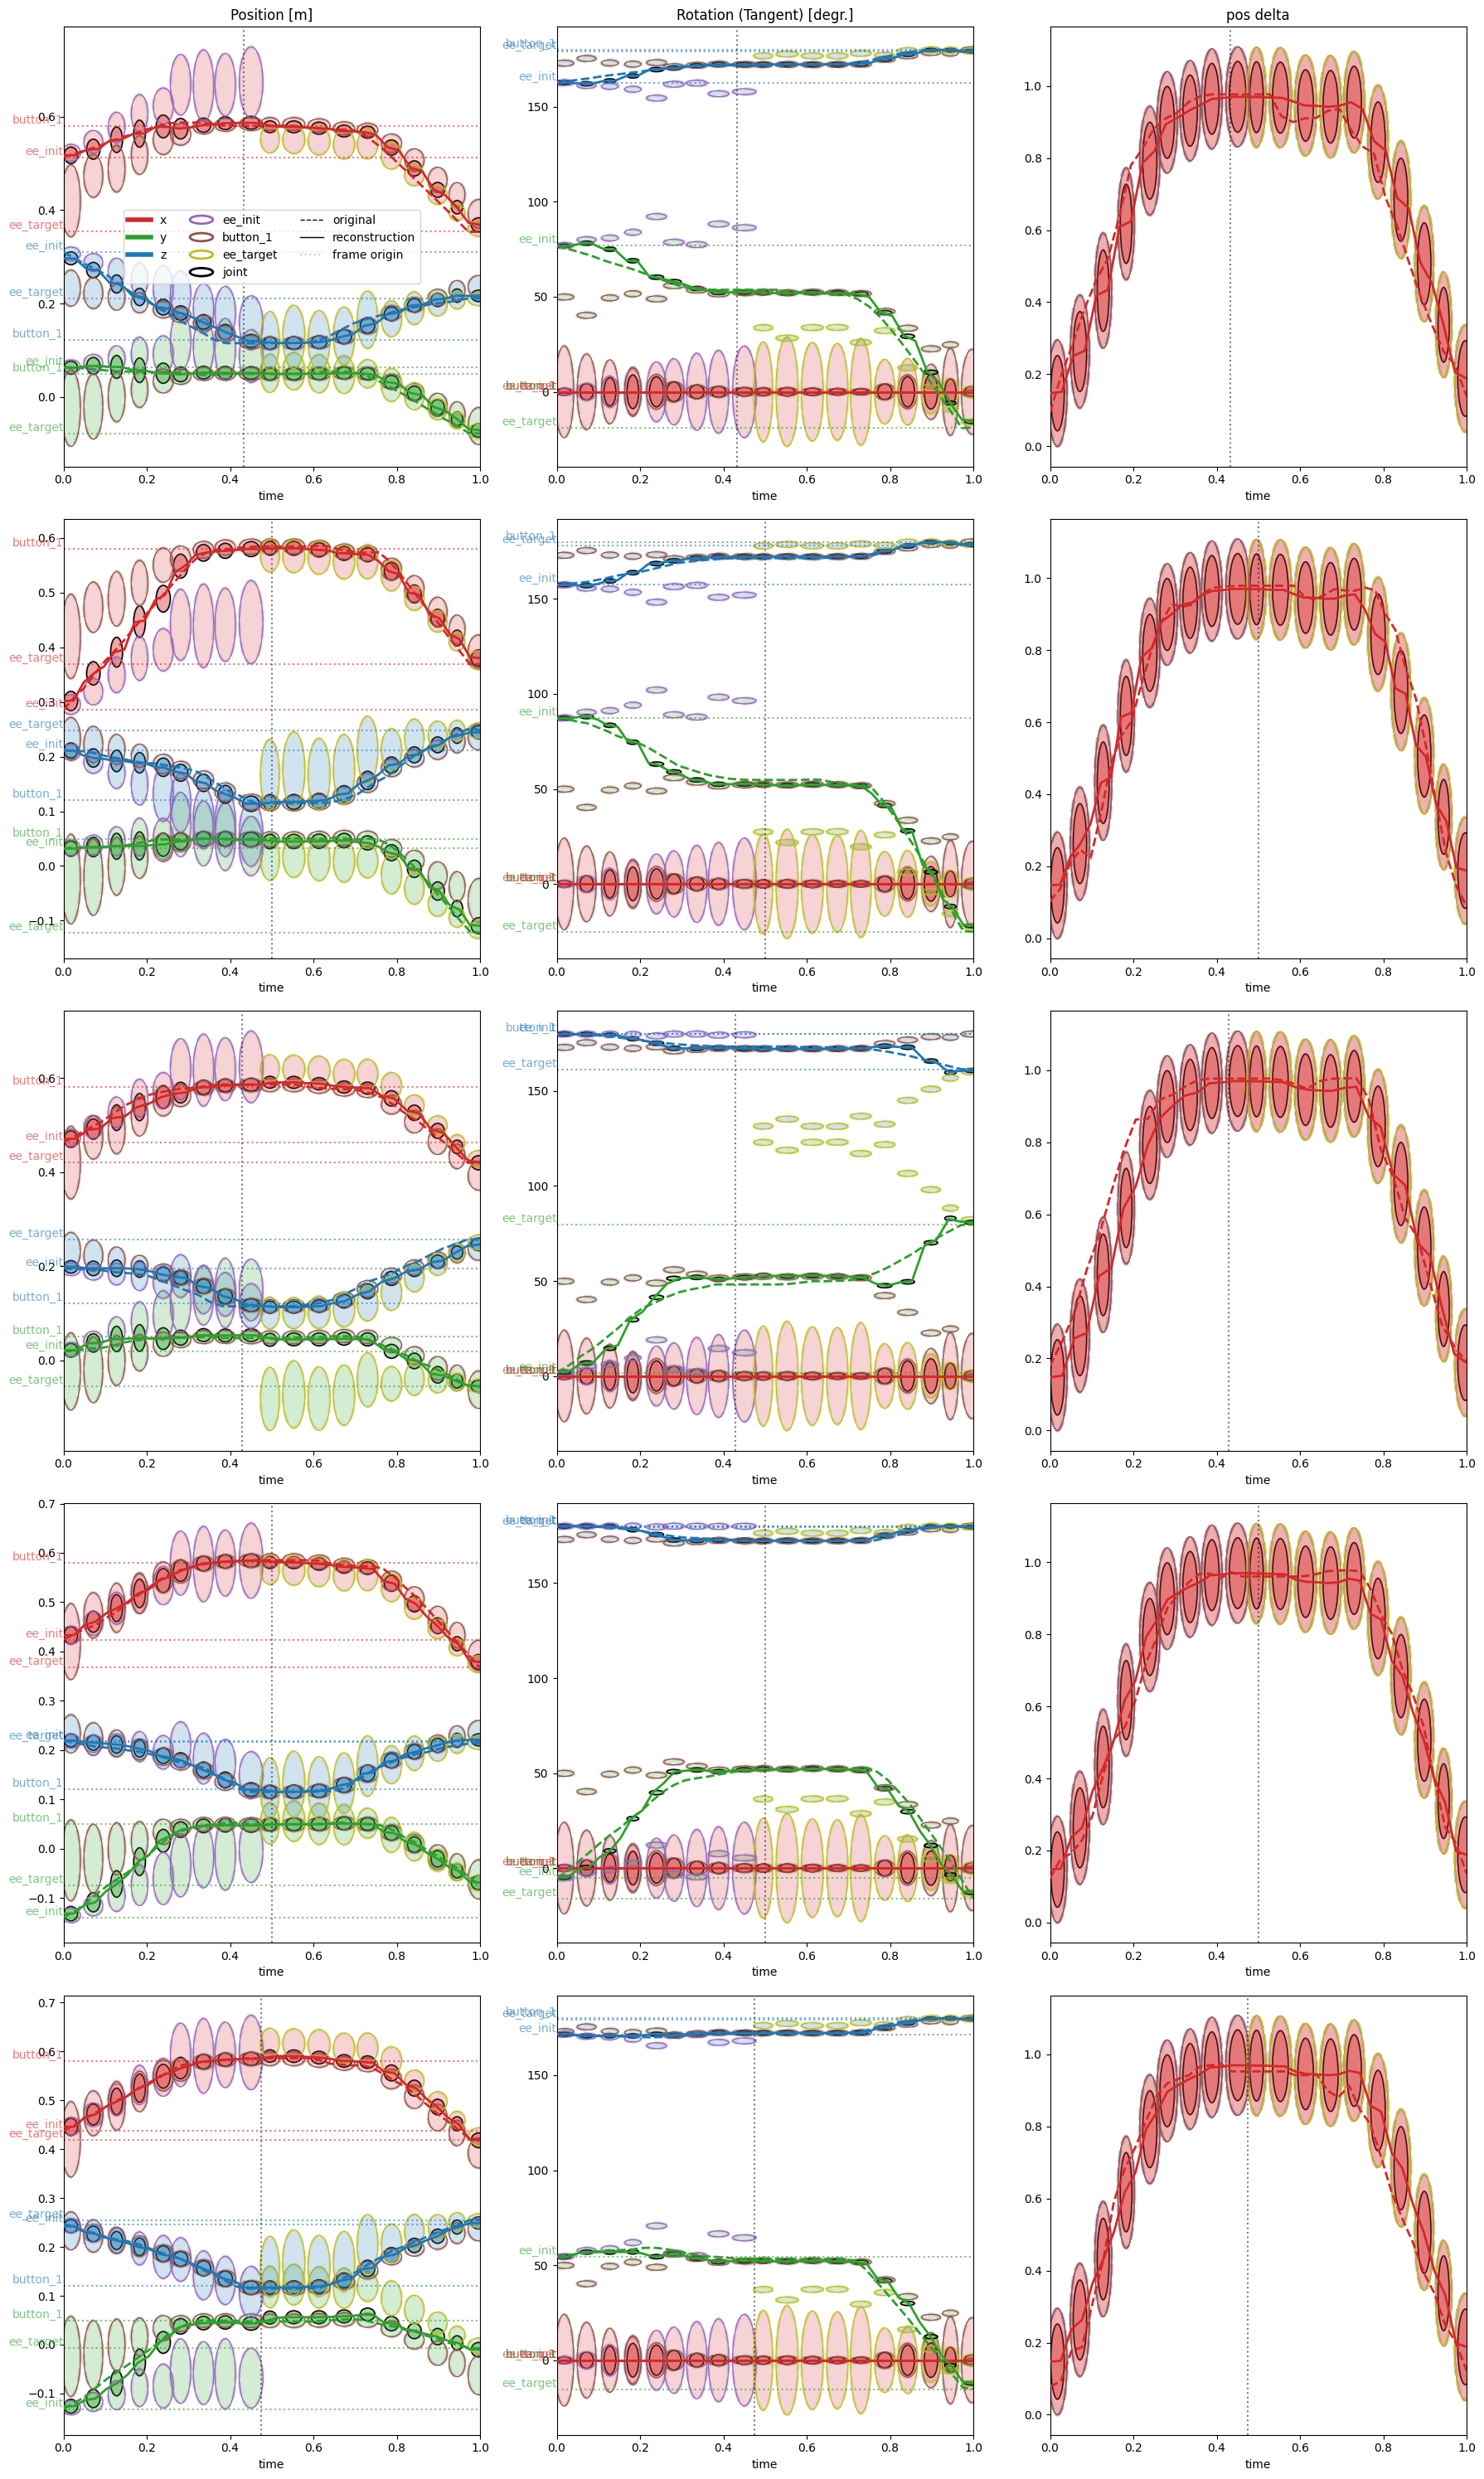

In [12]:
agent.model.plot_reconstructions(
    seg_trans_marg_container,
    cascaded_hmms,
    reconstructions,
    original_trajectories,
    plot_trajectories=True,
    plot_reconstructions=True,
    plot_gaussians=True,
    time_based=True,
    equal_aspect=False,
    per_segment=False,
)

In [13]:
agent.model.plot_reconstructions(
    seg_trans_marginals,
    seg_joint_models,
    reconstructions,
    original_trajectories,
    plot_trajectories=True,
    plot_reconstructions=True,
    plot_gaussians=True,
    time_based=False,
    equal_aspect=True,
    per_segment=False,
)

IndexError: tuple index out of range